# Shortcut Learning & Model Merging on CelebA
### Deep Learning and Applied AI - Sapienza University of Rome, 2025/2026

CelebA is naturally imbalanced: 94.3% of blond people in the dataset are female. A model trained with standard ERM picks up on this spurious correlation and predicts *blond hair* largely through *gender*, rather than actual hair color. The result is high average accuracy (~94%) but very poor performance on G3 (Blond/Male, ~1% of training data), with WGA dropping to ~22%.

We study whether model merging can correct this bias without retraining. We train a specialist on the underrepresented male subgroups and merge it with ERM using five strategies (Naive Merge, Task Arithmetic, Layer-Selective TA, Ensemble Logit, Fisher Merging). Upsampling and Group DRO serve as retrained upper bounds.

We install the required libraries and define all global configuration used throughout the notebook: device, checkpoint directory, training hyperparameters (batch size, epochs, lr, weight decay) and standard ImageNet transforms with random crop and flip for training. A fixed seed ensures reproducibility.

## 1. Global setup and imports

In [ ]:
!pip install -q datasets torch torchvision
print('Dependencies ready.')

Dependencies ready.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, Subset
from torchvision import transforms, models
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict, Counter
import copy, time, json, random, os
import json as _json
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

In [ ]:
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

NUM_CLASSES = 2
NUM_GROUPS  = 4
GROUP_NAMES = {0:'Not Blond / Female', 1:'Not Blond / Male',
               2:'Blond / Female',     3:'Blond / Male'}

BATCH_SIZE  = 128
NUM_WORKERS = 2
EPOCHS_ERM  = 10
LR_ERM      = 1e-4
WD_ERM      = 1e-4

TRAIN_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

EVAL_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

PT_DIR = '.'

Device : cuda
GPU    : Tesla T4


## 2. Dataset

We use CelebA with the official train/val/test splits from Sagawa et al. (2020). The prediction task is Blond\_Hair, the spurious attribute is Male. Train and val are subsampled to 20% (stratified by group) to fit Colab compute, the test set is kept at full size. Each sample is assigned a group index: G0 = Not Blond/Female, G1 = Not Blond/Male, G2 = Blond/Female, G3 = Blond/Male.

In [ ]:
hf_train = load_dataset('tpremoli/CelebA-attrs', split='train')
hf_val   = load_dataset('tpremoli/CelebA-attrs', split='validation')
hf_test  = load_dataset('tpremoli/CelebA-attrs', split='test')
print(f'Train: {len(hf_train)} | Val: {len(hf_val)} | Test: {len(hf_test)}')

Train: 162770 | Val: 19962 | Test: 19867


In [ ]:
class CelebADataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.data      = hf_dataset
        self.transform = transform or EVAL_TRANSFORM

        blond_col = np.array(hf_dataset['Blond_Hair'])
        male_col  = np.array(hf_dataset['Male'])

        self.labels = (blond_col == 1).astype(np.int8)
        self.males  = (male_col  == 1).astype(np.int8)
        self.groups = (2 * self.labels + self.males).astype(np.int8)

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        img = self.data[idx]['image'].convert('RGB')
        return self.transform(img), int(self.labels[idx]), int(self.groups[idx]), int(self.males[idx])


def subsample_dataset(dataset, fraction=0.2, seed=42):
    rng = np.random.default_rng(seed)
    indices = []
    for gid in range(NUM_GROUPS):
        gidx = np.where(dataset.groups == gid)[0]
        n_keep = max(1, int(len(gidx) * fraction))
        indices.extend(rng.choice(gidx, size=n_keep, replace=False).tolist())
    rng.shuffle(indices)
    return Subset(dataset, indices)

In [ ]:
FRACTION = 0.2

train_dataset = CelebADataset(hf_train, transform=TRAIN_TRANSFORM)
val_dataset   = CelebADataset(hf_val,   transform=EVAL_TRANSFORM)
test_dataset  = CelebADataset(hf_test,  transform=EVAL_TRANSFORM)

train_dataset_small = subsample_dataset(train_dataset, fraction=FRACTION)
val_dataset_small   = subsample_dataset(val_dataset,   fraction=FRACTION)

print(f'\nSubsampled train : {len(train_dataset_small)}')
print(f'Subsampled val   : {len(val_dataset_small)}')
print(f'Test (full)      : {len(test_dataset)}')

blond_mask = train_dataset.labels == 1
pct_female_blond = (1 - train_dataset.males[blond_mask]).mean() * 100
print(f'\nSpurious correlation: {pct_female_blond:.1f}% of blond people are female')


Subsampled train : 32552
Subsampled val   : 3992
Test (full)      : 19867

Spurious correlation: 94.3% of blond people are female


## 3. Data visualization

Two plots illustrate the shortcut learning problem before any model is trained. The first shows group sizes in the training set: G3 (Blond/Male) accounts for only ~0.9% of samples, small enough that ERM can reach very low average loss by ignoring it entirely. The second shows that 94.3% of blond people in the dataset are female, this is the spurious correlation that ERM ends up exploiting.

/tmp/ipykernel_1867/3831199310.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=15, ha='right', fontsize=9)


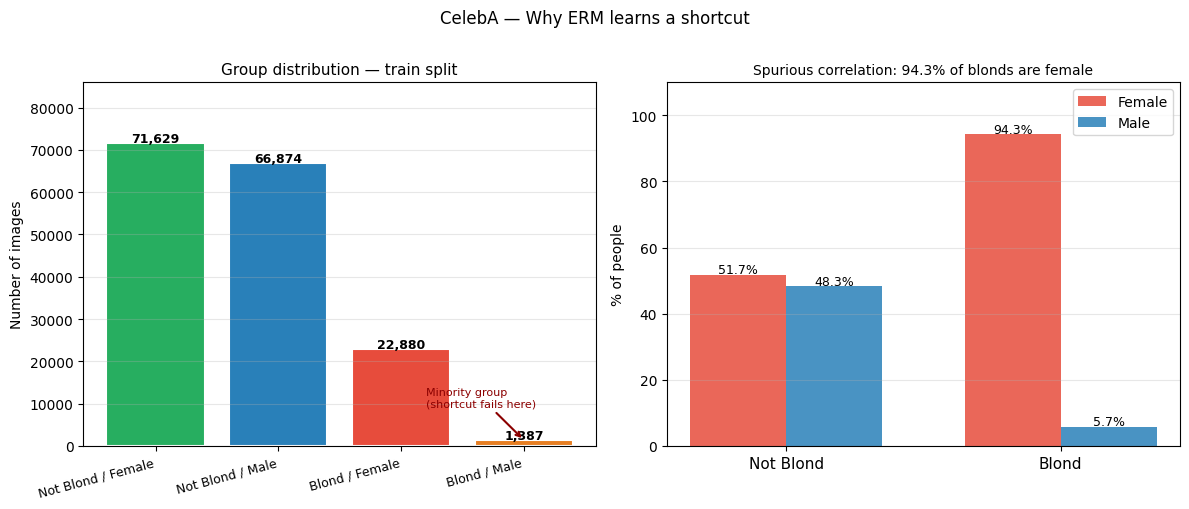

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
GROUP_COLORS = ['#27ae60', '#2980b9', '#e74c3c', '#e67e22']

ax = axes[0]
counts_train = Counter(train_dataset.groups)
vals  = [counts_train[g] for g in range(NUM_GROUPS)]
names = [GROUP_NAMES[g] for g in range(NUM_GROUPS)]
bars  = ax.bar(names, vals, color=GROUP_COLORS, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{v:,}', ha='center', fontsize=9, fontweight='bold')
ax.annotate('Minority group\n(shortcut fails here)', xy=(3, counts_train[3]),
            xytext=(2.2, counts_train[3] + 8000), fontsize=8, color='darkred',
            arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5))
ax.set_title('Group distribution — train split', fontsize=11)
ax.set_ylabel('Number of images')
ax.set_xticklabels(names, rotation=15, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.3); ax.set_ylim(0, max(vals) * 1.2)

ax = axes[1]
blond_idx    = train_dataset.labels == 1
nonblond_idx = train_dataset.labels == 0
pct_f_blond    = (1 - train_dataset.males[blond_idx]).mean()    * 100
pct_f_nonblond = (1 - train_dataset.males[nonblond_idx]).mean() * 100
pct_m_blond    = train_dataset.males[blond_idx].mean()    * 100
pct_m_nonblond = train_dataset.males[nonblond_idx].mean() * 100
x = np.arange(2); w = 0.35
b1 = ax.bar(x - w/2, [pct_f_nonblond, pct_f_blond], w, label='Female', color='#e74c3c', alpha=0.85)
b2 = ax.bar(x + w/2, [pct_m_nonblond, pct_m_blond], w, label='Male',   color='#2980b9', alpha=0.85)
for bar, v in zip(list(b1)+list(b2), [pct_f_nonblond, pct_f_blond, pct_m_nonblond, pct_m_blond]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{v:.1f}%', ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(['Not Blond', 'Blond'], fontsize=11)
ax.set_ylabel('% of people')
ax.set_title(f'Spurious correlation: {pct_f_blond:.1f}% of blonds are female', fontsize=10)
ax.legend(fontsize=10); ax.set_ylim(0, 110); ax.grid(axis='y', alpha=0.3)

plt.suptitle('CelebA — Why ERM learns a shortcut', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('fig_data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Model architecture and evaluation metrics

We use a ResNet-50 pretrained on ImageNet with the last FC layer replaced, following Sagawa et al. (2020). The key metric is Worst-Group Accuracy (WGA): the accuracy on the least-accurate group. A large gap between average accuracy and WGA is the signature of shortcut learning.

In [ ]:
def build_model():
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    return model.to(DEVICE)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct_g, total_g = defaultdict(int), defaultdict(int)
    correct_all = total_all = 0
    for imgs, labels, groups, _ in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        preds   = model(imgs).argmax(dim=1)
        correct = (preds == labels).cpu()
        for gid in range(NUM_GROUPS):
            mask = (groups == gid)
            correct_g[gid] += correct[mask].sum().item()
            total_g[gid]   += mask.sum().item()
        correct_all += correct.sum().item()
        total_all   += imgs.size(0)
    per_group = {gid: correct_g[gid] / max(total_g[gid], 1) for gid in range(NUM_GROUPS)}
    return {'avg_acc': correct_all / total_all, 'worst_group': min(per_group.values()),
            'per_group': per_group, 'per_group_n': dict(total_g)}


def print_results(results, name='Model'):
    print(f'\n── {name} ──')
    print(f'  Overall accuracy  : {results["avg_acc"]*100:.1f}%')
    print(f'  Worst-group (WGA) : {results["worst_group"]*100:.1f}%')
    print(f'  Gap               : {(results["avg_acc"]-results["worst_group"])*100:.1f} pts')
    for gid in range(NUM_GROUPS):
        acc  = results['per_group'][gid]
        n    = results['per_group_n'].get(gid, 0)
        flag = '  <- WORST' if acc == results['worst_group'] else ''
        print(f'    G{gid} {GROUP_NAMES[gid]:<22}: {acc*100:.1f}%  (n={n}){flag}')


_m = build_model()
_x = torch.randn(2, 3, 224, 224).to(DEVICE)
assert _m(_x).shape == (2, 2)
print(f'ResNet-50 output: {_m(_x).shape} | Params: {sum(p.numel() for p in _m.parameters())/1e6:.1f}M')
del _m, _x

ResNet-50 output: torch.Size([2, 2]) | Params: 23.5M


## 5. Sampling strategies and dataLoaders

The three training strategies differ only in how batches are composed: architecture, loss, and optimizer are identical.

| Strategy | G0 Not Blond/F | G1 Not Blond/M | G2 Blond/F | G3 Blond/M |
|----------|:-:|:-:|:-:|:-:|
| ERM | ~44% | ~41% | ~14% | ~0.9% |
| UW | 25% | 25% | 25% | 25% |
| Specialized-Men | — | 50% | — | 50% |

UW (Sagawa et al. 2020) balances all groups equally. Specialized-Men trains exclusively on male subgroups G1 and G3, making it a targeted expert for the cases where ERM fails.

In [ ]:
def make_sampler(dataset, mode='uw'):
    groups = (np.array([dataset.dataset.groups[i] for i in dataset.indices])
              if hasattr(dataset, 'indices') else dataset.groups)
    n = len(groups)
    weights = np.ones(n, dtype=np.float32)
    if mode == 'uw':
        counts = Counter(groups)
        for i, gid in enumerate(groups): weights[i] = 1.0 / counts[gid]
    elif mode == 'specialized':
        target_pct = {0: 0.10, 1: 0.10, 2: 0.10, 3: 0.70}
        counts = Counter(groups)
        group_w = {gid: target_pct[gid] / counts[gid] for gid in range(NUM_GROUPS)}
        for i, gid in enumerate(groups): weights[i] = group_w[gid]
    return WeightedRandomSampler(weights=weights, num_samples=len(weights), replacement=True)


def make_sampler_men_only(dataset):
    """Sample only G1 and G3 (male subgroups) at 50/50."""
    groups = (np.array([dataset.dataset.groups[i] for i in dataset.indices])
              if hasattr(dataset, 'indices') else dataset.groups)
    weights = np.zeros(len(groups), dtype=np.float32)
    counts = Counter(groups)
    for gid, pct in {1: 0.5, 3: 0.5}.items():
        if counts[gid] > 0:
            gw = pct / counts[gid]
            for i, g in enumerate(groups):
                if g == gid: weights[i] = gw
    return WeightedRandomSampler(weights=weights, num_samples=len(weights), replacement=True)


In [ ]:
train_loader_erm = DataLoader(train_dataset_small, batch_size=BATCH_SIZE,
                               shuffle=True, num_workers=NUM_WORKERS,
                               pin_memory=(DEVICE.type=='cuda'), prefetch_factor=2)

train_loader_uw = DataLoader(train_dataset_small, batch_size=BATCH_SIZE,
                              sampler=make_sampler(train_dataset_small, 'uw'),
                              num_workers=NUM_WORKERS, prefetch_factor=2)

train_loader_spec = DataLoader(train_dataset_small, batch_size=BATCH_SIZE,
                                sampler=make_sampler_men_only(train_dataset_small),
                                num_workers=NUM_WORKERS, prefetch_factor=2)

val_loader  = DataLoader(val_dataset_small, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset,      batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f'Train ERM  : {len(train_loader_erm)} batches')
print(f'Train UW   : {len(train_loader_uw)} batches')
print(f'Train Spec : {len(train_loader_spec)} batches')
print(f'Val / Test : {len(val_loader)} / {len(test_loader)} batches')

Train ERM  : 255 batches
Train UW   : 255 batches
Train Spec : 255 batches
Val / Test : 32 / 156 batches


## 6. Training loop

`train_model` implements SGD with momentum, a cosine scheduler, and early stopping on WGA (for robust models) or average accuracy (for ERM). The best checkpoint is saved and reloaded at the end. `GroupDROLoss` extends standard cross-entropy by maintaining a per-group weight vector updated via exponentiated gradient, it requires group labels at every forward pass, unlike ERM and UW which only need them for sampling.

In [ ]:
def train_model(model, train_loader, val_loader, epochs, lr, weight_decay,
                model_name='Model', patience=3, monitor='wga'):
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()
    best_metric, best_state, no_improve = 0.0, None, 0
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        loss_sum = correct = total = 0
        for imgs, labels, _, _ in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            logits = model(imgs)
            loss   = criterion(logits, labels)
            loss.backward(); optimizer.step()
            loss_sum += loss.item() * imgs.size(0)
            correct  += (logits.argmax(1) == labels).sum().item()
            total    += imgs.size(0)

        val    = evaluate(model, val_loader)
        metric = val['worst_group'] if monitor == 'wga' else val['avg_acc']

        if metric > best_metric:
            best_metric = metric
            best_state  = copy.deepcopy(model.state_dict())
            no_improve  = 0
        else:
            no_improve += 1

        if epoch % 5 == 0 or epoch == 1 or epoch == epochs:
            print(f'[{model_name}] Epoch {epoch:3d}/{epochs} | '
                  f'loss {loss_sum/total:.4f} | train {correct/total:.3f} | '
                  f'val avg {val["avg_acc"]:.3f} | val WGA {val["worst_group"]:.3f} | '
                  f'no_improve {no_improve}/{patience} | {time.time()-t0:.0f}s')

        if no_improve >= patience:
            print(f'Early stopping at epoch {epoch} (no {monitor} improvement for {patience} epochs)')
            break

    model.load_state_dict(best_state)
    print(f'Best val {monitor}: {best_metric:.3f} | Total: {time.time()-t0:.0f}s')
    return model, {}

In [ ]:
class GroupDROLoss(nn.Module):
    """
    Group DRO loss (Sagawa et al. 2020).
    Maintains group weights q updated via exponentiated gradient to upweight the worst group.
    """
    def __init__(self, num_groups=4, step_size=0.01, device=DEVICE):
        super().__init__()
        self.num_groups = num_groups
        self.step_size  = step_size
        self.device     = device
        self.q = torch.ones(num_groups).to(device) / num_groups

    def forward(self, logits, labels, group_ids):
        losses       = F.cross_entropy(logits, labels, reduction='none')
        group_losses = torch.zeros(self.num_groups).to(self.device)
        for i in range(self.num_groups):
            mask = (group_ids == i)
            if mask.sum() > 0:
                group_losses[i] = losses[mask].mean()
        with torch.no_grad():
            self.q = self.q * torch.exp(self.step_size * group_losses)
            self.q = self.q / self.q.sum()
        return (group_losses * self.q).sum()


def train_model_dro(model, train_loader, val_loader, epochs, lr, weight_decay,
                    step_size=0.01, patience=5):
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    criterion = GroupDROLoss(num_groups=NUM_GROUPS, step_size=step_size, device=DEVICE)
    best_wga, best_state, no_improve = 0.0, None, 0
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        loss_sum = total = 0
        for imgs, labels, groups, _ in train_loader:
            imgs, labels, groups = imgs.to(DEVICE), labels.to(DEVICE), groups.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels, groups)
            loss.backward(); optimizer.step()
            loss_sum += loss.item() * imgs.size(0)
            total    += imgs.size(0)

        val = evaluate(model, val_loader)
        if val['worst_group'] > best_wga:
            best_wga   = val['worst_group']
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1

        print(f'[Group DRO] Epoch {epoch:2d}/{epochs} | loss {loss_sum/total:.4f} | '
              f'val avg {val["avg_acc"]:.3f} | val WGA {val["worst_group"]:.3f} | '
              f'no_improve {no_improve}/{patience}')

        if no_improve >= patience:
            print(f'Early stopping at epoch {epoch}')
            break

    model.load_state_dict(best_state)
    print(f'DRO done in {time.time()-t0:.0f}s | Best val WGA: {best_wga:.3f}')
    return model

## 7. Model training

We train four models: ERM (biased baseline), UW (balanced sampling), Specialized-Men (male expert, merge partner), and Group DRO (oracle). If a `.pt` checkpoint already exists in `PT_DIR`, it is loaded directly; otherwise the model is trained and saved. The pretrained ImageNet weights are also saved before any CelebA training, they serve as the reference point θ₀ for Task Arithmetic.

In [ ]:
if os.path.exists(f'{PT_DIR}/model_pretrained.pt'):
    model_pretrained = build_model()
    model_pretrained.load_state_dict(torch.load(f'{PT_DIR}/model_pretrained.pt', map_location=DEVICE))
    model_pretrained.eval()
    print('model_pretrained.pt loaded.')
else:
    model_pretrained = build_model()
    torch.save(model_pretrained.state_dict(), f'{PT_DIR}/model_pretrained.pt')
    model_pretrained.eval()
    print('model_pretrained.pt saved.')


model_pretrained.pt loaded.


### 7.1 Empirical Risk Minimization (ERM)

Standard training on the natural (biased) distribution. Expected to achieve ~94% average accuracy but very low WGA due to shortcut learning.

In [ ]:
if os.path.exists(f'{PT_DIR}/model_erm.pt'):
    model_erm = build_model()
    model_erm.load_state_dict(torch.load(f'{PT_DIR}/model_erm.pt', map_location=DEVICE))
    model_erm.eval()
    print('model_erm.pt loaded')
else:
    print('No checkpoint found — training ERM...')
    model_erm = build_model()
    model_erm, _ = train_model(model_erm, train_loader_erm, val_loader,
                                epochs=EPOCHS_ERM, lr=LR_ERM, weight_decay=WD_ERM,
                                model_name='ERM', patience=3, monitor='avg')
    torch.save(model_erm.state_dict(), f'{PT_DIR}/model_erm.pt')
    print('Checkpoint saved: model_erm.pt')

results_erm_test = evaluate(model_erm, test_loader)
print_results(results_erm_test, 'ERM — Test')

model_erm.pt loaded

── ERM — Test ──
  Overall accuracy  : 94.6%
  Worst-group (WGA) : 22.0%
  Gap               : 72.6 pts
    G0 Not Blond / Female    : 94.1%  (n=8535)
    G1 Not Blond / Male      : 99.6%  (n=8276)
    G2 Blond / Female        : 86.3%  (n=2874)
    G3 Blond / Male          : 22.0%  (n=182)  <- WORST


### 7.2 UW

`WeightedRandomSampler` with 25% per group. By balancing the training distribution, the model cannot exploit the majority group as a proxy for the label.

In [ ]:
if os.path.exists(f'{PT_DIR}/model_uw.pt'):
    model_uw = build_model()
    model_uw.load_state_dict(torch.load(f'{PT_DIR}/model_uw.pt', map_location=DEVICE))
    model_uw.eval()
    print('model_uw.pt loaded')
else:
    print('No checkpoint found — training UW...')
    model_uw = build_model()
    model_uw, _ = train_model(model_uw, train_loader_uw, val_loader,
                               epochs=EPOCHS_ERM, lr=LR_ERM, weight_decay=WD_ERM,
                               model_name='UW', patience=3, monitor='wga')
    torch.save(model_uw.state_dict(), f'{PT_DIR}/model_uw.pt')
    print('Checkpoint saved: model_uw.pt')

results_uw_test = evaluate(model_uw, test_loader)
print_results(results_uw_test, 'UW — Test')

model_uw.pt loaded

── UW — Test ──
  Overall accuracy  : 88.9%
  Worst-group (WGA) : 83.5%
  Gap               : 5.4 pts
    G0 Not Blond / Female    : 84.8%  (n=8535)
    G1 Not Blond / Male      : 91.2%  (n=8276)
    G2 Blond / Female        : 94.9%  (n=2874)
    G3 Blond / Male          : 83.5%  (n=182)  <- WORST


### 7.3 Specialized-Men

Trained exclusively on G1 and G3 (male subgroups, 50%/50%). Not evaluated as a standalone model, its role is to serve as the merge partner for ERM, providing a targeted correction for the cases where ERM fails.

In [ ]:
if os.path.exists(f'{PT_DIR}/model_specialized_men.pt'):
    model_spec = build_model()
    model_spec.load_state_dict(torch.load(f'{PT_DIR}/model_specialized_men.pt', map_location=DEVICE))
    model_spec.eval()
    print('model_specialized_men.pt loaded')
else:
    print('No checkpoint found — training Specialized-Men...')
    model_spec = build_model()
    model_spec, _ = train_model(model_spec, train_loader_spec, val_loader,
                                 epochs=EPOCHS_ERM, lr=LR_ERM, weight_decay=WD_ERM,
                                 model_name='Specialized-Men', patience=5, monitor='wga')
    torch.save(model_spec.state_dict(), f'{PT_DIR}/model_specialized_men.pt')
    print('Checkpoint saved: model_specialized_men.pt')

results_spec_test = evaluate(model_spec, test_loader)
print_results(results_spec_test, 'Specialized-Men — Test')

model_specialized_men.pt loaded

── Specialized-Men — Test ──
  Overall accuracy  : 86.3%
  Worst-group (WGA) : 77.4%
  Gap               : 8.9 pts
    G0 Not Blond / Female    : 77.4%  (n=8535)  <- WORST
    G1 Not Blond / Male      : 92.5%  (n=8276)
    G2 Blond / Female        : 94.7%  (n=2874)
    G3 Blond / Male          : 85.2%  (n=182)


### 7.4 Group DRO

At each step, per-group losses are computed and the group weight vector is updated to upweight the worst-performing group. Unlike UW, group labels are required throughout training, not just for sampling.

In [ ]:
if os.path.exists(f'{PT_DIR}/model_dro.pt'):
    model_dro = build_model()
    model_dro.load_state_dict(torch.load(f'{PT_DIR}/model_dro.pt', map_location=DEVICE))
    model_dro.eval()
    print('model_dro.pt loaded')
else:
    print('No checkpoint found — training Group DRO...')
    train_loader_dro = DataLoader(
        train_dataset_small, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS,
        prefetch_factor=2 if DEVICE.type == 'cuda' else None
    )
    model_dro = build_model()
    model_dro = train_model_dro(
        model_dro, train_loader_dro, val_loader,
        epochs=EPOCHS_ERM, lr=LR_ERM,
        weight_decay=0.1,
        step_size=0.01,
        patience=5
    )
    torch.save(model_dro.state_dict(), f'{PT_DIR}/model_dro.pt')
    print('Checkpoint saved: model_dro.pt')

results_dro_test = evaluate(model_dro, test_loader)
print_results(results_dro_test, 'Group DRO — Test')

model_dro.pt loaded

── Group DRO — Test ──
  Overall accuracy  : 90.9%
  Worst-group (WGA) : 86.8%
  Gap               : 4.1 pts
    G0 Not Blond / Female    : 88.6%  (n=8535)
    G1 Not Blond / Male      : 92.6%  (n=8276)
    G2 Blond / Female        : 93.6%  (n=2874)
    G3 Blond / Male          : 86.8%  (n=182)  <- WORST


## 8. Model merging

We explore four ways to combine ERM and Specialized-Men without any additional training. ERM has learned a strong general representation but fails on G3; Specialized-Men is expert exactly where ERM is weakest. The goal is to get the best of both without retraining.

| Method | Space | Cost |
|--------|-------|------|
| Naive Merge | Weights | none |
| Task Arithmetic | Weights (task vector) | none |
| Ensemble Logit | Logits | 2× inference |
| Fisher Merging | Weights (Fisher-weighted) | ~1 batch |

### 8.1 Naive merge

Direct linear interpolation in weight space: **θ = (1−α)·θ_ERM + α·θ_Spec**. We sweep α from 0 to 1.

In [ ]:
ALPHAS = [round(a, 1) for a in np.arange(0.0, 1.01, 0.1)]

def naive_merge(model_a, model_b, alpha):
    """θ_merged = (1-alpha)*θ_a + alpha*θ_b"""
    merged = build_model()
    sd_a, sd_b, sd_m = model_a.state_dict(), model_b.state_dict(), {}
    for key in sd_a:
        sd_m[key] = (1 - alpha) * sd_a[key].float() + alpha * sd_b[key].float()
    merged.load_state_dict(sd_m)
    return merged

In [ ]:
print('Naive Merge — ERM + Specialized-Men')
print(f'{"Alpha":>6} | {"Avg acc":>8} | {"WGA":>8}')
print('-' * 32)

results_naive = {'alpha': ALPHAS, 'avg': [], 'wga': [], 'per_group': []}
best_naive_model = None
for alpha in ALPHAS:
    merged = naive_merge(model_erm, model_spec, alpha)
    res = evaluate(merged, test_loader)
    results_naive['avg'].append(res['avg_acc'])
    results_naive['wga'].append(res['worst_group'])
    results_naive['per_group'].append(res['per_group'].copy())
    print(f'{alpha:>6.1f} | {res["avg_acc"]*100:>7.1f}% | {res["worst_group"]*100:>7.1f}%')
    if best_naive_model is None or res['worst_group'] > max(results_naive['wga'][:-1], default=0):
        best_naive_model = merged

best_idx = int(np.argmax(results_naive['wga']))
print(f'\nBest α : {ALPHAS[best_idx]:.1f} → WGA {results_naive["wga"][best_idx]*100:.1f}% | '
      f'Avg {results_naive["avg"][best_idx]*100:.1f}%')

torch.save(best_naive_model.state_dict(), f'{PT_DIR}/merge_naive_best.pt')

Naive Merge — ERM + Specialized-Men
 Alpha |  Avg acc |      WGA
--------------------------------
   0.0 |    94.6% |    22.0%
   0.1 |    94.6% |    20.9%
   0.2 |    94.6% |    21.4%
   0.3 |    94.4% |    22.0%
   0.4 |    94.3% |    29.1%
   0.5 |    93.8% |    33.0%
   0.6 |    93.0% |    46.7%
   0.7 |    91.8% |    64.8%
   0.8 |    90.1% |    73.6%
   0.9 |    88.2% |    80.2%
   1.0 |    86.3% |    77.4%

Best α : 0.9 → WGA 80.2% | Avg 88.2%


### 8.2 Task Arithmetic

The task vector τ_Spec = θ_Spec − θ_pretrained captures what the specialist learned relative to the ImageNet initialization. Adding it to ERM injects the specialist's correction while keeping ERM's base knowledge (Ilharco et al. 2023):

**θ_merged = θ_ERM + λ · τ_Spec**

In [ ]:
def compute_task_vector(model_ft, model_pre):
    """τ = θ_finetuned − θ_pretrained. FC and BN buffers excluded (set to zero)."""
    sd_ft, sd_pre, tau = model_ft.state_dict(), model_pre.state_dict(), {}
    for key in sd_ft:
        if any(x in key for x in ['fc', 'num_batches_tracked', 'running_mean', 'running_var']):
            tau[key] = torch.zeros_like(sd_ft[key].float())
        else:
            tau[key] = sd_ft[key].float() - sd_pre[key].float()
    return tau


def task_arithmetic_merge(model_erm, tau_partner, lam):
    """θ_merged = θ_ERM + λ·τ_partner  (Ilharco et al. 2023)"""
    merged = build_model()
    sd_erm, sd_m = model_erm.state_dict(), {}
    for key in sd_erm:
        sd_m[key] = sd_erm[key].float() + lam * tau_partner[key]
    merged.load_state_dict(sd_m)
    return merged

In [ ]:
LAMBDAS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.2, 1.5, 2.0]

tau_spec = compute_task_vector(model_spec, model_pretrained)

print('Task Arithmetic — ERM + Specialized-Men')
print(f'Formula: θ_ERM + λ·τ_Spec')
print(f'{"Lambda":>8} | {"Avg acc":>8} | {"WGA":>8}')
print('-' * 34)

results_ta = {'lambda': LAMBDAS, 'avg': [], 'wga': [], 'per_group': []}
best_ta_model = None
for lam in LAMBDAS:
    merged = task_arithmetic_merge(model_erm, tau_spec, lam)
    res = evaluate(merged, test_loader)
    results_ta['avg'].append(res['avg_acc'])
    results_ta['wga'].append(res['worst_group'])
    results_ta['per_group'].append(res['per_group'].copy())
    print(f'{lam:>8.2f} | {res["avg_acc"]*100:>7.1f}% | {res["worst_group"]*100:>7.1f}%')
    if best_ta_model is None or res['worst_group'] > max(results_ta['wga'][:-1], default=0):
        best_ta_model = merged

best_idx = int(np.argmax(results_ta['wga']))
print(f'\nBest λ : {LAMBDAS[best_idx]} → WGA {results_ta["wga"][best_idx]*100:.1f}% | '
      f'Avg {results_ta["avg"][best_idx]*100:.1f}%')

torch.save(best_ta_model.state_dict(), f'{PT_DIR}/merge_ta_best.pt')

Task Arithmetic — ERM + Specialized-Men
Formula: θ_ERM + λ·τ_Spec
  Lambda |  Avg acc |      WGA
----------------------------------
    0.10 |    94.6% |    25.3%
    0.20 |    94.5% |    30.8%
    0.30 |    94.3% |    36.3%
    0.40 |    94.2% |    40.7%
    0.50 |    94.0% |    45.1%
    0.60 |    93.7% |    48.9%
    0.70 |    93.5% |    54.9%
    0.80 |    93.1% |    60.4%
    0.90 |    92.8% |    65.4%
    1.00 |    92.4% |    68.7%
    1.20 |    91.6% |    73.1%
    1.50 |    90.7% |    82.4%
    2.00 |    89.0% |    84.7%

Best λ : 2.0 → WGA 84.7% | Avg 89.0%


### 8.3 Layer-Selective Task Arithmetic

Standard Task Arithmetic applies the same λ to every layer. In ResNet-50, early layers encode low-level features shared with ImageNet, while later layers encode the task-specific decision where the spurious correlation is learned. We apply a stronger correction to late layers and a weaker one to stable early layers: layer1/layer2 × 0.2, layer3 × 0.5, layer4 + fc × 1.0, then sweep global λ. This is motivated by the hierarchical structure of the network and is our own adaptation of Task Arithmetic.

In [ ]:
def layer_selective_ta(model_erm, tau, lam):
    merged = build_model()
    sd_erm, sd_m = model_erm.state_dict(), {}
    for key in sd_erm:
        if key.startswith('layer4') or key.startswith('fc'):
            scale = 1.0
        elif key.startswith('layer3'):
            scale = 0.5
        else:
            scale = 0.2
        sd_m[key] = sd_erm[key].float() + lam * scale * tau[key]
    merged.load_state_dict(sd_m)
    return merged


In [ ]:
LAMBDAS_LS = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 2.5, 3.0]

print('Layer-Selective Task Arithmetic — ERM + Specialized-Men')
print(f'{"Lambda":>8} | {"Avg acc":>8} | {"WGA":>8}')
print('-' * 34)

results_ls = {'lambda': LAMBDAS_LS, 'avg': [], 'wga': [], 'per_group': []}
best_ls_model = None
for lam in LAMBDAS_LS:
    merged = layer_selective_ta(model_erm, tau_spec, lam)
    res = evaluate(merged, test_loader)
    results_ls['avg'].append(res['avg_acc'])
    results_ls['wga'].append(res['worst_group'])
    results_ls['per_group'].append(res['per_group'].copy())
    print(f'{lam:>8.2f} | {res["avg_acc"]*100:>7.1f}% | {res["worst_group"]*100:>7.1f}%')
    if best_ls_model is None or res['worst_group'] > max(results_ls['wga'][:-1], default=0):
        best_ls_model = merged

best_idx = int(np.argmax(results_ls['wga']))
print(f'\nBest λ : {LAMBDAS_LS[best_idx]} → WGA {results_ls["wga"][best_idx]*100:.1f}% | '
      f'Avg {results_ls["avg"][best_idx]*100:.1f}%')

torch.save(best_ls_model.state_dict(), f'{PT_DIR}/merge_lsta_best.pt')

Layer-Selective Task Arithmetic — ERM + Specialized-Men
  Lambda |  Avg acc |      WGA
----------------------------------
    0.50 |    94.2% |    41.2%
    0.80 |    93.5% |    50.5%
    1.00 |    93.0% |    59.9%
    1.20 |    92.5% |    65.9%
    1.50 |    91.6% |    75.3%
    2.00 |    90.1% |    84.6%
    2.50 |    88.7% |    83.1%
    3.00 |    87.6% |    81.9%

Best λ : 2.0 → WGA 84.6% | Avg 90.1%


### 8.4 Ensemble Logit

Instead of merging weights, we average the output logits at inference time: **logits = (1−α)·logits_ERM + α·logits_Spec**. This is an output-space baseline from Wortsman et al. (2022) — it requires keeping both models in memory (2× inference cost), unlike the weight-space methods above.

In [ ]:
ALPHAS = [round(a, 1) for a in np.arange(0.0, 1.01, 0.1)]

@torch.no_grad()
def evaluate_logit_ensemble(model_a, model_b, loader, alpha):
    """logits = (1-alpha)*logits_a + alpha*logits_b. Cost: 2 forward passes/batch."""
    model_a.eval(); model_b.eval()
    correct_g, total_g = defaultdict(int), defaultdict(int)
    correct_all = total_all = 0
    for imgs, labels, groups, _ in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits  = (1 - alpha) * model_a(imgs) + alpha * model_b(imgs)
        preds   = logits.argmax(dim=1)
        correct = (preds == labels).cpu()
        for gid in range(NUM_GROUPS):
            mask = (groups == gid)
            correct_g[gid] += correct[mask].sum().item()
            total_g[gid]   += mask.sum().item()
        correct_all += correct.sum().item()
        total_all   += imgs.size(0)
    per_group = {gid: correct_g[gid] / max(total_g[gid], 1) for gid in range(NUM_GROUPS)}
    return {'avg_acc': correct_all/total_all, 'worst_group': min(per_group.values()),
            'per_group': per_group, 'per_group_n': dict(total_g)}

In [ ]:
print('Ensemble Logit — ERM + Specialized-Men')
print(f'{"Alpha":>6} | {"Avg acc":>8} | {"WGA":>8}')
print('-' * 32)

results_ens = {'alpha': ALPHAS, 'avg': [], 'wga': [], 'per_group': []}
for alpha in ALPHAS:
    res = evaluate_logit_ensemble(model_erm, model_spec, test_loader, alpha)
    results_ens['avg'].append(res['avg_acc'])
    results_ens['wga'].append(res['worst_group'])
    results_ens['per_group'].append(res['per_group'].copy())
    print(f'{alpha:>6.1f} | {res["avg_acc"]*100:>7.1f}% | {res["worst_group"]*100:>7.1f}%')

best_idx = int(np.argmax(results_ens['wga']))
best_ens_alpha = ALPHAS[best_idx]
print(f'\nBest α : {best_ens_alpha:.1f} → WGA {results_ens["wga"][best_idx]*100:.1f}% | '
      f'Avg {results_ens["avg"][best_idx]*100:.1f}%')

with open(f'{PT_DIR}/merge_ensemble_config.json', 'w') as _f:
    _json.dump({'best_alpha': best_ens_alpha,
                'model_a': f'{PT_DIR}/model_erm.pt',
                'model_b': f'{PT_DIR}/model_specialized_men.pt'}, _f)

Ensemble Logit — ERM + Specialized-Men
 Alpha |  Avg acc |      WGA
--------------------------------
   0.0 |    94.6% |    22.0%
   0.1 |    94.6% |    26.9%
   0.2 |    94.4% |    32.4%
   0.3 |    94.0% |    35.7%
   0.4 |    93.7% |    47.8%
   0.5 |    93.1% |    59.3%
   0.6 |    92.3% |    69.2%
   0.7 |    91.3% |    73.1%
   0.8 |    89.9% |    75.8%
   0.9 |    88.3% |    80.8%
   1.0 |    86.3% |    77.4%

Best α : 0.9 → WGA 80.8% | Avg 88.3%


### 8.5 Fisher merging

Each parameter is weighted by its Fisher information, an estimate of how much it influences the model's predictions (Matena & Raffel, NeurIPS 2022):

$$\theta_{merged}[k] = \frac{F_{ERM}[k]\cdot\theta_{ERM}[k] + F_{Spec}[k]\cdot\theta_{Spec}[k]}{F_{ERM}[k] + F_{Spec}[k]}$$

We compute Fisher on a balanced validation set (UW sampler). Using the biased val set would cause ERM's Fisher to be high on spurious features — it is very confident about the shortcut — and would make it dominate the merge precisely where it is wrong.

In [ ]:
val_loader_balanced = DataLoader(
    val_dataset_small, batch_size=BATCH_SIZE,
    sampler=make_sampler(val_dataset_small, mode='uw'),
    num_workers=NUM_WORKERS,
    )


def compute_fisher(model, loader, num_batches=50):
    model.eval()
    fisher = {n: torch.zeros_like(p.data) for n, p in model.named_parameters()}
    count  = 0
    for imgs, labels, _, _ in loader:
        if count >= num_batches: break
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        model.zero_grad()
        nn.CrossEntropyLoss()(model(imgs), labels).backward()
        for n, p in model.named_parameters():
            if p.grad is not None: fisher[n] += p.grad.data.pow(2)
        count += 1
    for n in fisher: fisher[n] /= max(count, 1)
    return fisher


def normalize_fisher(fisher):
    return {n: f / (f.norm() + 1e-8) for n, f in fisher.items()}


@torch.no_grad()
def fisher_merge(model_a, model_b, fisher_a, fisher_b):
    merged = build_model()
    sd_a, sd_b = model_a.state_dict(), model_b.state_dict()
    param_keys = set(fisher_a.keys())
    sd_m = {}
    for key in sd_a:
        if key in param_keys:
            fa, fb = fisher_a[key].clamp(min=0), fisher_b[key].clamp(min=0)
            sd_m[key] = (fa * sd_a[key].float() + fb * sd_b[key].float()) / (fa + fb + 1e-8)
        else:
            sd_m[key] = 0.5 * (sd_a[key].float() + sd_b[key].float())
    merged.load_state_dict(sd_m)
    return merged

In [ ]:
fisher_erm  = normalize_fisher(compute_fisher(model_erm,  val_loader_balanced))
fisher_spec = normalize_fisher(compute_fisher(model_spec, val_loader_balanced))

model_fisher   = fisher_merge(model_erm, model_spec, fisher_erm, fisher_spec)
results_fisher = evaluate(model_fisher, test_loader)
print_results(results_fisher, 'Fisher Merge — ERM + Specialized')
torch.save(model_fisher.state_dict(), f'{PT_DIR}/merge_fisher.pt')


── Fisher Merge — ERM + Specialized ──
  Overall accuracy  : 91.2%
  Worst-group (WGA) : 66.5%
  Gap               : 24.7 pts
    G0 Not Blond / Female    : 85.1%  (n=8535)
    G1 Not Blond / Male      : 96.9%  (n=8276)
    G2 Blond / Female        : 94.4%  (n=2874)
    G3 Blond / Male          : 66.5%  (n=182)  <- WORST


## 9. Results summary

For each merging method, the hyperparameter (α or λ) that maximises WGA on the validation set is selected, and the corresponding test accuracy is reported. Selecting by average accuracy would trivially favour α = 0 (pure ERM), which has the highest average accuracy by design. Methods marked **†** require group labels throughout training and act as upper bounds.

In [ ]:
def best_of(d, key_wga, key_avg):
    idx = int(np.argmax(d[key_wga]))
    return d[key_wga][idx]*100, d[key_avg][idx]*100

best_naive_wga, best_naive_avg = best_of(results_naive, 'wga', 'avg')
best_ta_wga,    best_ta_avg    = best_of(results_ta,    'wga', 'avg')
best_ens_wga,   best_ens_avg   = best_of(results_ens,   'wga', 'avg')
best_ls_wga,    best_ls_avg    = best_of(results_ls,    'wga', 'avg')

W = 72
print('\n' + '=' * W)
print(f'{"Method":<38} {"Avg":>7} {"WGA":>7} {"Retrain?":>9}')
print('-' * W)

rows = [
    ('── Baselines ──────────────────────────', None, None, None),
    ('ERM (shortcut baseline)',
     results_erm_test['avg_acc']*100, results_erm_test['worst_group']*100, 'no'),
    ('UW (Sagawa et al. 2020)',
     results_uw_test['avg_acc']*100,  results_uw_test['worst_group']*100,  'yes'),
    ('Group DRO (Sagawa et al. 2020)',
     results_dro_test['avg_acc']*100, results_dro_test['worst_group']*100, 'yes'),
    ('── ERM + Specialized-Men ──────────────', None, None, None),
    ('Naive Merge (best α)',         best_naive_avg, best_naive_wga, 'no'),
    ('Task Arithmetic (best λ)',     best_ta_avg,    best_ta_wga,    'no'),
    ('Layer-Selective TA (best λ)',  best_ls_avg,    best_ls_wga,    'no'),
    ('Ensemble Logit (best α)',      best_ens_avg,   best_ens_wga,   'no'),
    ('Fisher Merging',
     results_fisher['avg_acc']*100,  results_fisher['worst_group']*100, 'no'),
]

for row in rows:
    name, avg, wga, retrain = row
    if avg is None:
        print(f'  {name}')
    else:
        print(f'{name:<38} {avg:>6.1f}% {wga:>6.1f}% {retrain:>9}')

print('=' * W)

all_wgas  = [best_naive_wga, best_ta_wga, best_ls_wga, best_ens_wga,
             results_fisher['worst_group']*100]
all_names = ['Naive', 'Task Arithmetic', 'Layer-Selective TA', 'Ensemble Logit', 'Fisher']
best_i = int(np.argmax(all_wgas))
print(f'\nBest merge  : {all_names[best_i]} — WGA {all_wgas[best_i]:.1f}%')
print(f'ERM baseline: WGA {results_erm_test["worst_group"]*100:.1f}%'
      f'  (+{all_wgas[best_i] - results_erm_test["worst_group"]*100:.1f} pts without retraining)')
print(f'Gap to DRO  : {results_dro_test["worst_group"]*100 - all_wgas[best_i]:.1f} pts')


Method                                     Avg     WGA  Retrain?
------------------------------------------------------------------------
  ── Baselines ──────────────────────────
ERM (shortcut baseline)                  94.6%   22.0%        no
UW (Sagawa et al. 2020)                  88.9%   83.5%       yes
Group DRO (Sagawa et al. 2020)           90.9%   86.8%       yes
  ── ERM + Specialized-Men ──────────────
Naive Merge (best α)                     88.2%   80.2%        no
Task Arithmetic (best λ)                 89.0%   84.7%        no
Layer-Selective TA (best λ)              90.1%   84.6%        no
Ensemble Logit (best α)                  88.3%   80.8%        no
Fisher Merging                           91.2%   66.5%        no

Best merge  : Task Arithmetic — WGA 84.7%
ERM baseline: WGA 22.0%  (+62.7 pts without retraining)
Gap to DRO  : 2.1 pts


In [ ]:
def best_of(d, key_wga, key_avg):
    idx = int(np.argmax(d[key_wga]))
    return d[key_wga][idx]*100, d[key_avg][idx]*100

best_naive_wga, best_naive_avg = best_of(results_naive, 'wga', 'avg')
best_ta_wga,    best_ta_avg    = best_of(results_ta,    'wga', 'avg')
best_ens_wga,   best_ens_avg   = best_of(results_ens,   'wga', 'avg')

W = 60
print('\n' + '=' * W)
print(f'{"Method":<38} {"Avg":>7} {"WGA":>7}')
print('-' * W)

rows = [
    ('── Baselines ──────────────────────────', None, None),
    ('ERM (shortcut baseline)',
     results_erm_test['avg_acc']*100, results_erm_test['worst_group']*100),
    ('UW (Sagawa et al. 2020)',
     results_uw_test['avg_acc']*100,  results_uw_test['worst_group']*100),
    ('Group DRO (Sagawa et al. 2020)',
     results_dro_test['avg_acc']*100, results_dro_test['worst_group']*100),
    ('── ERM + Specialized-Men ──────────────', None, None),
    ('Naive Merge (best α)',         best_naive_avg, best_naive_wga),
    ('Task Arithmetic (best λ)',     best_ta_avg,    best_ta_wga),
    ('Ensemble Logit (best α)',      best_ens_avg,   best_ens_wga),
    ('Fisher Merging',
     results_fisher['avg_acc']*100,  results_fisher['worst_group']*100),
]

for row in rows:
    name, avg, wga = row
    if avg is None:
        print(f'  {name}')
    else:
        print(f'{name:<38} {avg:>6.1f}% {wga:>6.1f}%')

print('=' * W)

all_wgas  = [best_naive_wga, best_ta_wga, best_ens_wga,
             results_fisher['worst_group']*100]
all_names = ['Naive', 'Task Arithmetic', 'Ensemble Logit', 'Fisher']
best_i = int(np.argmax(all_wgas))
print(f'\nBest merge  : {all_names[best_i]} — WGA {all_wgas[best_i]:.1f}%')
print(f'ERM baseline: WGA {results_erm_test["worst_group"]*100:.1f}%'
      f'  (+{all_wgas[best_i] - results_erm_test["worst_group"]*100:.1f} pts without retraining)')
print(f'Gap to DRO  : {results_dro_test["worst_group"]*100 - all_wgas[best_i]:.1f} pts')


Method                                     Avg     WGA
------------------------------------------------------------
  ── Baselines ──────────────────────────
ERM (shortcut baseline)                  94.6%   22.0%
UW (Sagawa et al. 2020)                  88.9%   83.5%
Group DRO (Sagawa et al. 2020)           90.9%   86.8%
  ── ERM + Specialized-Men ──────────────
Naive Merge (best α)                     88.2%   80.2%
Task Arithmetic (best λ)                 89.0%   84.7%
Ensemble Logit (best α)                  88.3%   80.8%
Fisher Merging                           91.2%   66.5%

Best merge  : Task Arithmetic — WGA 84.7%
ERM baseline: WGA 22.0%  (+62.7 pts without retraining)
Gap to DRO  : 2.1 pts


## 10. Visualizations

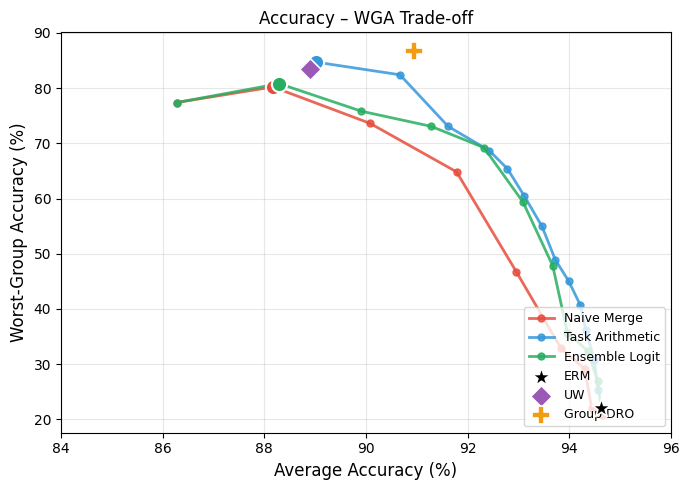

Saved: tradeoff.pdf / tradeoff.png


In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

for method, res, color in [
    ('Naive Merge',     results_naive, '#e74c3c'),
    ('Task Arithmetic', results_ta,    '#3498db'),
    ('Ensemble Logit',  results_ens,   '#27ae60'),
]:
    avgs = [a*100 for a in res['avg']]
    wgas = [w*100 for w in res['wga']]
    ax.plot(avgs, wgas, 'o-', color=color, label=method, linewidth=2, markersize=5, alpha=0.85)
    best_i = int(np.argmax(wgas))
    ax.scatter(avgs[best_i], wgas[best_i], color=color, s=120, zorder=6, edgecolors='white', linewidths=1.5)

baselines = [
    ('ERM',       results_erm_test['avg_acc']*100,  results_erm_test['worst_group']*100,  'k',       '*', 200),
    ('UW',        results_uw_test['avg_acc']*100,   results_uw_test['worst_group']*100,   '#9b59b6', 'D', 120),
    ('Group DRO', results_dro_test['avg_acc']*100,  results_dro_test['worst_group']*100,  '#f39c12', 'P', 150),
]
for name, avg, wga, color, marker, size in baselines:
    ax.scatter(avg, wga, color=color, marker=marker, s=size, label=name, zorder=7, edgecolors='white', linewidths=1.2)

ax.set_xlabel('Average Accuracy (%)', fontsize=12)
ax.set_ylabel('Worst-Group Accuracy (%)', fontsize=12)
ax.set_title('Accuracy – WGA Trade-off', fontsize=12)
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim(84, 96)

plt.tight_layout()
plt.savefig('tradeoff.pdf', bbox_inches='tight', dpi=150)
plt.savefig('tradeoff.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: tradeoff.pdf / tradeoff.png')

The first plot shows the average accuracy / WGA tradeoff curve as a function of the merging coefficient, this is the main figure for the report. 

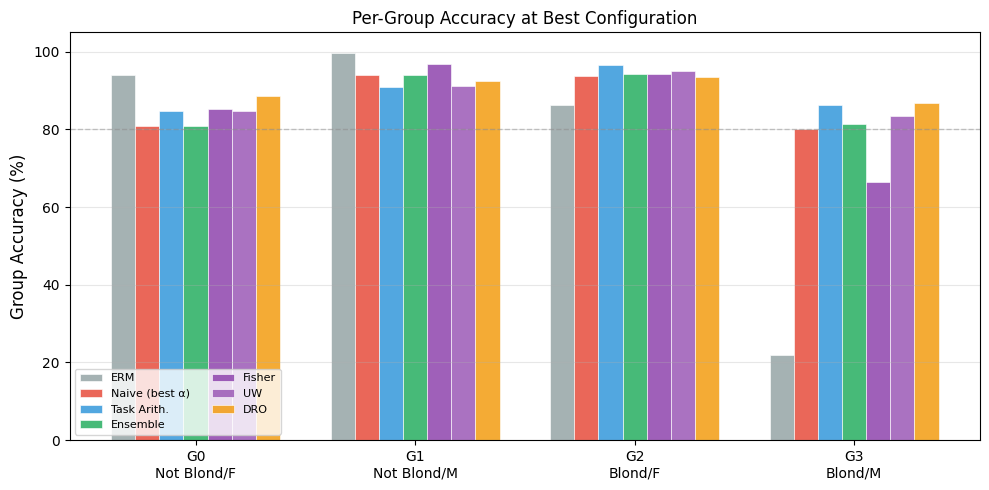

Saved: pergroup.pdf / pergroup.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

GROUP_LABELS = ['G0\nNot Blond/F', 'G1\nNot Blond/M', 'G2\nBlond/F', 'G3\nBlond/M']

best_naive_i = int(np.argmax(results_naive['wga']))
best_ta_i    = int(np.argmax(results_ta['wga']))
best_ens_i   = int(np.argmax(results_ens['wga']))

methods_pg = [
    ('ERM',            [results_erm_test['per_group'][g]*100 for g in range(4)],                        '#95a5a6'),
    ('Naive (best α)', [results_naive['per_group'][best_naive_i][g]*100 for g in range(4)],             '#e74c3c'),
    ('Task Arith.',    [results_ta['per_group'][best_ta_i][g]*100 for g in range(4)],                   '#3498db'),
    ('Ensemble',       [results_ens['per_group'][best_ens_i][g]*100 for g in range(4)],                 '#27ae60'),
    ('Fisher',         [results_fisher['per_group'][g]*100 for g in range(4)],                          '#8e44ad'),
    ('UW',             [results_uw_test['per_group'][g]*100 for g in range(4)],                         '#9b59b6'),
    ('DRO',            [results_dro_test['per_group'][g]*100 for g in range(4)],                        '#f39c12'),
]

x = np.arange(4)
n = len(methods_pg)
w = 0.11
offsets = np.linspace(-(n-1)*w/2, (n-1)*w/2, n)

for (name, vals, color), offset in zip(methods_pg, offsets):
    ax.bar(x + offset, vals, w, label=name, color=color, alpha=0.85, edgecolor='white', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(GROUP_LABELS, fontsize=10)
ax.set_ylabel('Group Accuracy (%)', fontsize=12)
ax.set_title('Per-Group Accuracy at Best Configuration', fontsize=12)
ax.legend(fontsize=8, loc='lower left', ncol=2)
ax.axhline(y=80, color='gray', linestyle='--', alpha=0.4, linewidth=1)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('pergroup.pdf', bbox_inches='tight', dpi=150)
plt.savefig('pergroup.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: pergroup.pdf / pergroup.png')

The second breaks down accuracy per group at the best configuration for each method, and goes to the appendix.

In [ ]:
@torch.no_grad()
def extract_features(model, loader, n_per_group=182):
    model.eval()
    backbone = nn.Sequential(*list(model.children())[:-1]).to(DEVICE)
    feats, grps = [], []
    counts = defaultdict(int)
    for imgs, _, groups, _ in loader:
        imgs = imgs.to(DEVICE)
        f = backbone(imgs).flatten(1).cpu().numpy()
        for i in range(len(imgs)):
            g = groups[i].item()
            if counts[g] < n_per_group:
                feats.append(f[i]); grps.append(g); counts[g] += 1
        if all(counts[g] >= n_per_group for g in range(NUM_GROUPS)):
            break
    return np.array(feats), np.array(grps)


best_naive_i = int(np.argmax(results_naive['wga']))
best_merge_for_tsne = naive_merge(model_erm, model_spec, ALPHAS[best_naive_i])

feats_erm,   grps_erm   = extract_features(model_erm,            test_loader)
feats_merge, grps_merge = extract_features(best_merge_for_tsne,  test_loader)
print(f'Done: {feats_erm.shape[0]} samples per model')

pca = PCA(n_components=50, random_state=42)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=500)
feats_erm_2d   = tsne.fit_transform(pca.fit_transform(feats_erm))
feats_merge_2d = tsne.fit_transform(pca.fit_transform(feats_merge))

Done: 728 samples per model


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


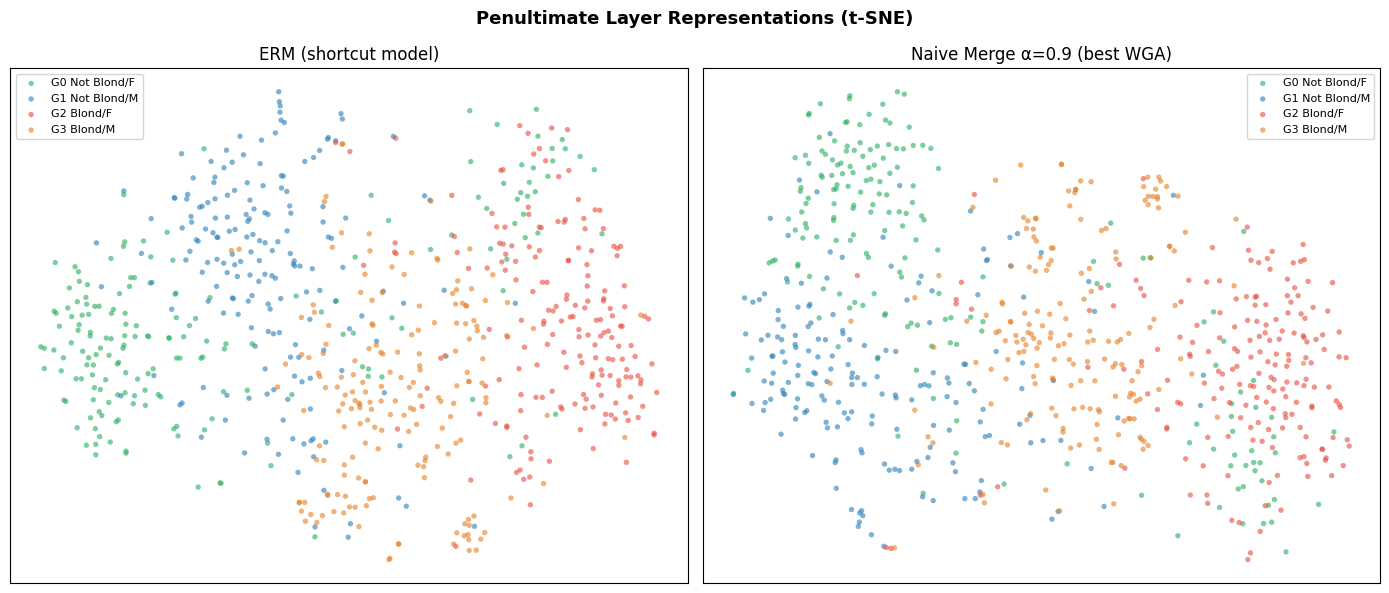

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
TSNE_COLORS = {0:'#27ae60', 1:'#2980b9', 2:'#e74c3c', 3:'#e67e22'}
TSNE_LABELS = {0:'G0 Not Blond/F', 1:'G1 Not Blond/M', 2:'G2 Blond/F', 3:'G3 Blond/M'}

for ax, feats_2d, grps, title in [
    (axes[0], feats_erm_2d,   grps_erm,   'ERM (shortcut model)'),
    (axes[1], feats_merge_2d, grps_merge, f'Naive Merge α={ALPHAS[best_naive_i]} (best WGA)'),
]:
    for gid in range(NUM_GROUPS):
        mask = grps == gid
        ax.scatter(feats_2d[mask, 0], feats_2d[mask, 1],
                   c=TSNE_COLORS[gid], label=TSNE_LABELS[gid],
                   alpha=0.6, s=15, edgecolors='none')
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle('Penultimate Layer Representations (t-SNE)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tsne_representations.pdf', bbox_inches='tight', dpi=150)
plt.savefig('tsne_representations.png', bbox_inches='tight', dpi=150)
plt.show()

We extract the 2048-d penultimate-layer activations on a balanced sample from the test set (182 images per group, 728 total). PCA first reduces to 50 dimensions, then t-SNE projects to 2D. We compare ERM, where the model conflates gender with hair color, to the best merged model, to check whether the correction is reflected in the internal representation. 

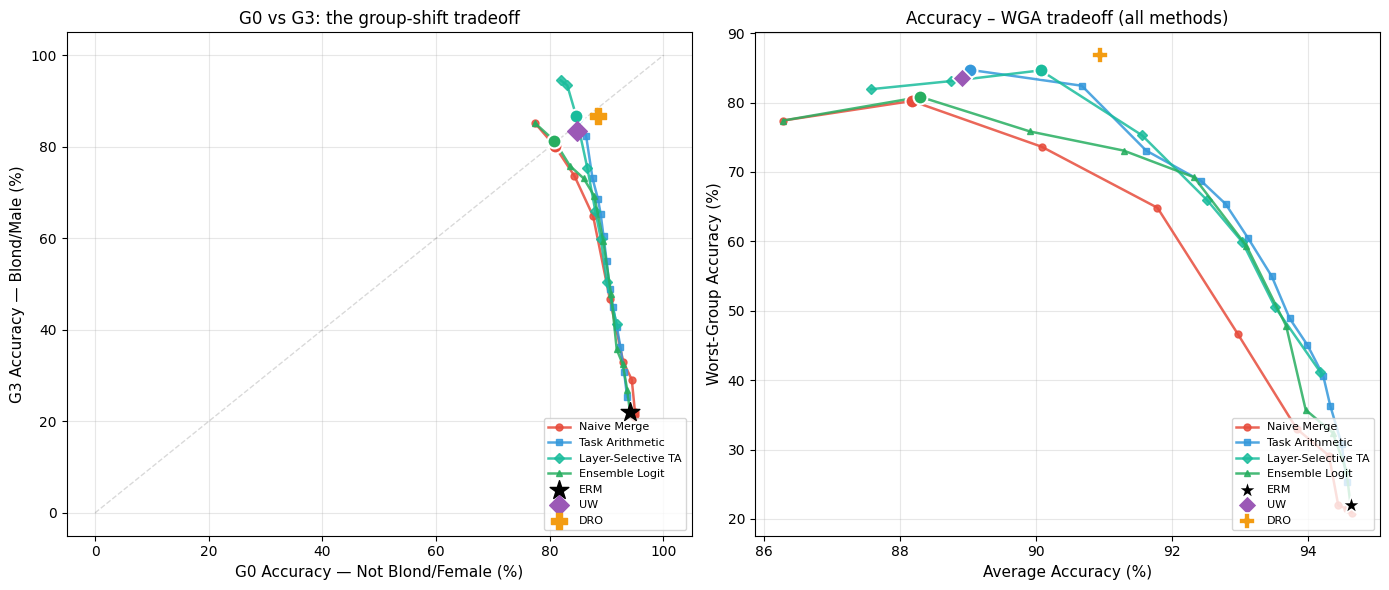

Saved: fig_pareto_tradeoff.pdf / .png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

METHOD_STYLES = [
    ('Naive Merge',        results_naive, '#e74c3c', 'o-'),
    ('Task Arithmetic',    results_ta,    '#3498db', 's-'),
    ('Layer-Selective TA', results_ls,    '#1abc9c', 'D-'),
    ('Ensemble Logit',     results_ens,   '#27ae60', '^-'),
]

ax = axes[0]
for name, res, color, style in METHOD_STYLES:
    g0 = [pg[0]*100 for pg in res['per_group']]
    g3 = [pg[3]*100 for pg in res['per_group']]
    ax.plot(g0, g3, style, color=color, label=name, linewidth=1.8, markersize=5, alpha=0.85)
    best_i = int(np.argmax(res['wga']))
    ax.scatter(g0[best_i], g3[best_i], color=color, s=100, zorder=6, edgecolors='white', linewidths=1.5)

ax.scatter(results_erm_test['per_group'][0]*100, results_erm_test['per_group'][3]*100,
           c='k', marker='*', s=200, label='ERM', zorder=7)
ax.scatter(results_uw_test['per_group'][0]*100,  results_uw_test['per_group'][3]*100,
           c='#9b59b6', marker='D', s=100, label='UW', zorder=7)
ax.scatter(results_dro_test['per_group'][0]*100, results_dro_test['per_group'][3]*100,
           c='#f39c12', marker='P', s=120, label='DRO', zorder=7)

ax.set_xlabel('G0 Accuracy — Not Blond/Female (%)', fontsize=11)
ax.set_ylabel('G3 Accuracy — Blond/Male (%)', fontsize=11)
ax.set_title('G0 vs G3: the group-shift tradeoff', fontsize=12)
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, alpha=0.3)
ax.plot([0,100],[0,100], 'k--', alpha=0.15, linewidth=1)

ax = axes[1]
for name, res, color, style in METHOD_STYLES:
    avgs = [a*100 for a in res['avg']]
    wgas = [w*100 for w in res['wga']]
    ax.plot(avgs, wgas, style, color=color, label=name, linewidth=1.8, markersize=5, alpha=0.85)
    best_i = int(np.argmax(wgas))
    ax.scatter(avgs[best_i], wgas[best_i], color=color, s=100, zorder=6, edgecolors='white', linewidths=1.5)

for name, avg, wga, c, mk, sz in [
    ('ERM', results_erm_test['avg_acc']*100,  results_erm_test['worst_group']*100,  'k', '*', 200),
    ('UW',  results_uw_test['avg_acc']*100,   results_uw_test['worst_group']*100,   '#9b59b6', 'D', 100),
    ('DRO', results_dro_test['avg_acc']*100,  results_dro_test['worst_group']*100,  '#f39c12', 'P', 120),
]:
    ax.scatter(avg, wga, c=c, marker=mk, s=sz, label=name, zorder=7, edgecolors='white', linewidths=1.2)

ax.set_xlabel('Average Accuracy (%)', fontsize=11)
ax.set_ylabel('Worst-Group Accuracy (%)', fontsize=11)
ax.set_title('Accuracy – WGA tradeoff (all methods)', fontsize=12)
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_pareto_tradeoff.pdf', bbox_inches='tight', dpi=150)
plt.savefig('fig_pareto_tradeoff.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_pareto_tradeoff.pdf / .png')


As the merging coefficient increases, the model corrects G3 (Blond/Male) but progressively hurts G0 (Not Blond/Female). The left plot traces G3 accuracy vs G0 accuracy as a parametric curve in α, the ideal method moves toward the top-right corner. The right plot shows WGA as a function of α for all methods.